In [1]:
import numpy as np
from scipy import integrate
import matplotlib.pyplot as plt

https://stackoverflow.com/questions/78985951/solving-a-set-of-coupled-ordinary-differential-equation-representing-the-coupled

$$
\begin{align}
\frac{dx_1}{dt} &= \alpha \left( y_1 - x_1 - f(x_1) \right) + \kappa (x_2 - x_1) \\
\frac{dy_1}{dt} &= x_1 - y_1 + z_1 \\
\frac{dz_1}{dt} &= -\beta y_1 \\
\frac{dx_2}{dt} &= \alpha \left( y_2 - x_2 - f(x_2) \right) + \kappa (x_1 - x_2) \\
\frac{dy_2}{dt} &= x_2 - y_2 + z_2 \\
\frac{dz_2}{dt} &= -\beta y_2 \\
f(x) &= m_2 x + 0.5 (m_1 - m_2) \left( |x + 1| - |x - 1| \right)
\end{align}
$$

In [2]:
def f(x, m1, m2):
    return m2 * x + (m1 - m2) / 2 * (np.abs(x + 1) - np.abs(x - 1))

In [3]:
alpha = 10 
beta = 14.87
kappa = 0.15
m1 = -1.27 
m2 = -0.68
p0 = (alpha, beta, kappa, m1, m2)

In [4]:
def model(t, x, alpha, beta, kappa, m1, m2):
    x1, y1, z1, x2, y2, z2 = x
    return np.array([
        alpha * (y1 - x1 - f(x1, m1, m2)) + kappa * (x2 - x1),
        x1 - y1 + z1,
        - beta * y1,
        alpha * (y2 - x2 - f(x2, m1, m2)) + kappa * (x1 - x2),
        x2 - y2 + z2,
        - beta * y2
    ])

In [5]:
t = np.linspace(0., 500., 10_000)

In [6]:
x0 = np.array([-2, 0.2, 4, 0.7, 0.4, -0.8])

In [7]:
sol = integrate.solve_ivp(model, [t.min(), t.max()], y0=x0, args=p0, t_eval=t, method="LSODA", atol=1e-12, rtol=1e-14)

/home/jlandercy/.local/lib/python3.10/site-packages/scipy/integrate/_ivp/ivp.py:621: UserWarning: At least one element of `rtol` is too small. Setting `rtol = np.maximum(rtol, 2.220446049250313e-14)`.
  solver = method(fun, t0, y0, tf, vectorized=vectorized, **options)


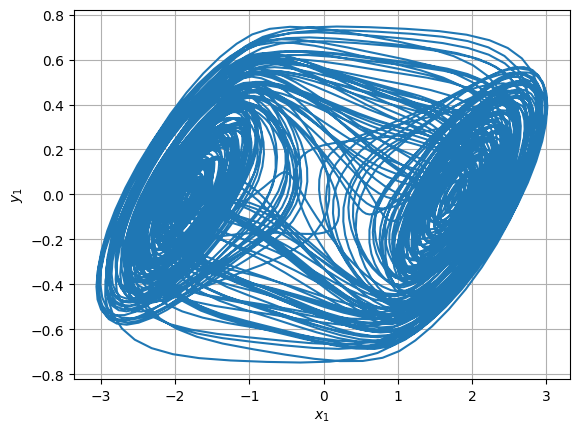

In [8]:
fig, axe = plt.subplots()
axe.plot(sol.y[0], sol.y[1])
axe.set_xlabel("$x_1$")
axe.set_ylabel("$y_1$")
axe.grid()

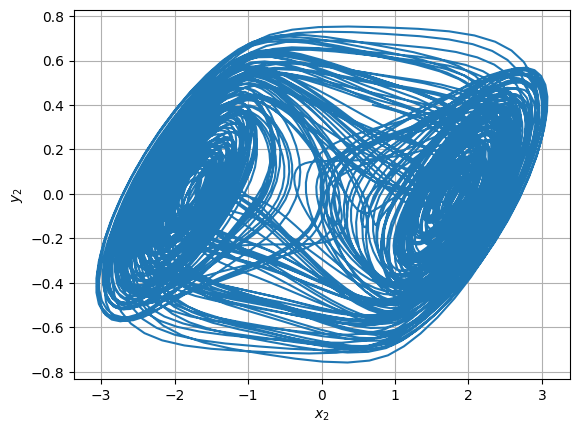

In [9]:
fig, axe = plt.subplots()
axe.plot(sol.y[3], sol.y[4])
axe.set_xlabel("$x_2$")
axe.set_ylabel("$y_2$")
axe.grid()

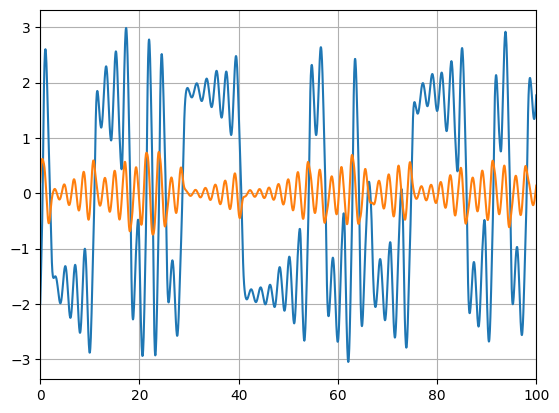

In [10]:
fig, axe = plt.subplots()
axe.plot(t, sol.y[0])
axe.plot(t, sol.y[1])
axe.set_xlim([0, 100])
axe.grid()

In [11]:
np.__version__

'2.0.1'

'1.14.0'

In [13]:
import scipy

In [15]:
scipy.__version__

'1.14.0'